# Asheboro BoE Bachelors Degree Outputs

In [ ]:
# Import the necessary packages
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
BASE_DIR = Path(__file__ + "/../../../Simulation Results/Ballots/Asheboro Sims").resolve()

In [ ]:
# read in dfs
bt_df = pd.read_csv(BASE_DIR / "ashe_sims_Asheboro BoE Bachelors Degree_ballots_BT.csv")
pl_df = pd.read_csv(BASE_DIR / "ashe_sims_Asheboro BoE Bachelors Degree_ballots_PL.csv")
cam_df = pd.read_csv(BASE_DIR / "ashe_sims_Asheboro BoE Bachelors Degree_ballots_Cam.csv")

num_winners = 3 #We need to define this per race
num_votes = 1000 #We can calculate this but I'm too lazy to write the code for it right now


### Clean up the Dataframes

In [3]:
# Right now, rankings are a string. We can turn this into a list, seperating entries on the comma
# We want to expand this so that each vote ranking gets its own row

# BT
candidates = bt_df['ranking'].str.split(",", expand=True)

column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

bt_df = pd.concat([candidates, bt_df.drop('ranking', axis=1)], axis=1)

# Store num_candidates for later:
num_candidates = len(candidates.columns)


# PL
candidates = pl_df['ranking'].str.split(",", expand=True)

column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

pl_df = pd.concat([candidates, pl_df.drop('ranking', axis=1)], axis=1)

# Cam
candidates = cam_df['ranking'].str.split(",", expand=True)

column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

cam_df = pd.concat([candidates, cam_df.drop('ranking', axis=1)], axis=1)

## Plot average percentage in Plurality

In [4]:
num_iterations = len(bt_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
bt_df_plur = bt_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_bt = bt_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    bt_df_plur = bt_df[['Vote_1', f'iteration_{i}']]
    temp_df = bt_df_plur.groupby('Vote_1').sum().reset_index()
    final_bt = pd.merge(final_bt, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

In [5]:
num_iterations = len(pl_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
pl_df_plur = pl_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_pl = pl_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    pl_df_plur = pl_df[['Vote_1', f'iteration_{i}']]
    temp_df = pl_df_plur.groupby('Vote_1').sum().reset_index()
    final_pl = pd.merge(final_pl, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

In [6]:
num_iterations = len(cam_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
cam_df_plur = cam_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_cam = pl_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    cam_df_plur = cam_df[['Vote_1', f'iteration_{i}']]
    temp_df = cam_df_plur.groupby('Vote_1').sum().reset_index()
    final_cam = pd.merge(final_cam, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

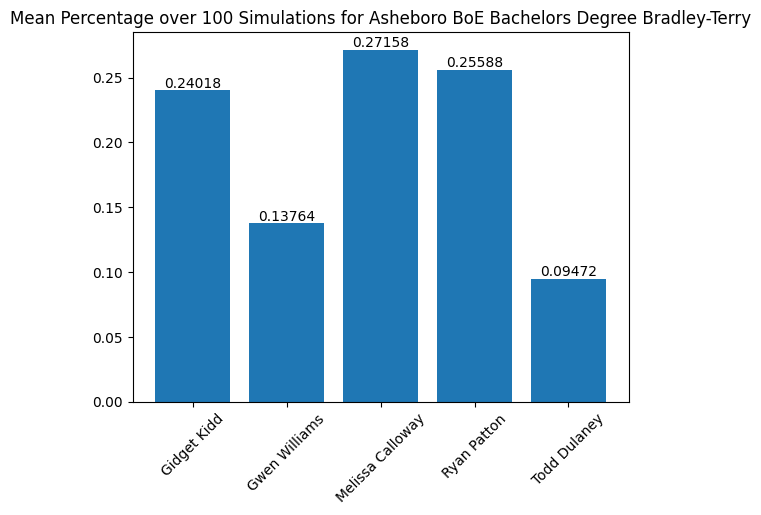

In [7]:
# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_bt = final_bt.astype({col: int for col in final_bt.columns[1:]})
final_bt = final_bt.assign(mean=final_bt.mean(axis=1, numeric_only=True))
final_bt['mean_perc'] = final_bt['mean']/num_votes

fig, ax = plt.subplots()
ax.bar(final_bt['Vote_1'], final_bt['mean_perc'])
ax.tick_params(axis='x', labelrotation=45)
plt.title(f"Mean Percentage over {num_iterations} Simulations for Asheboro BoE Bachelors Degree Bradley-Terry")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

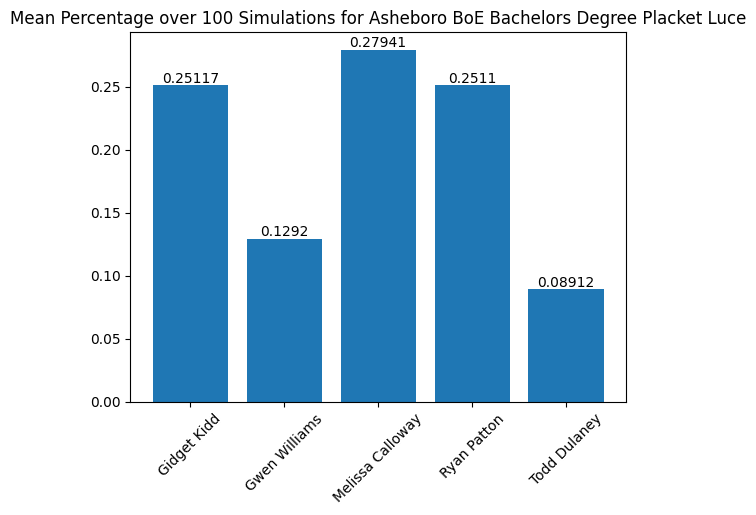

In [8]:
# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_pl = final_pl.astype({col: int for col in final_pl.columns[1:]})
final_pl = final_pl.assign(mean=final_pl.mean(axis=1, numeric_only=True))
final_pl['mean_perc'] = final_pl['mean']/num_votes

fig, ax = plt.subplots()
ax.bar(final_pl['Vote_1'], final_pl['mean_perc'])
ax.tick_params(axis='x', labelrotation=45)
plt.title(f"Mean Percentage over {num_iterations} Simulations for Asheboro BoE Bachelors Degree Placket Luce")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

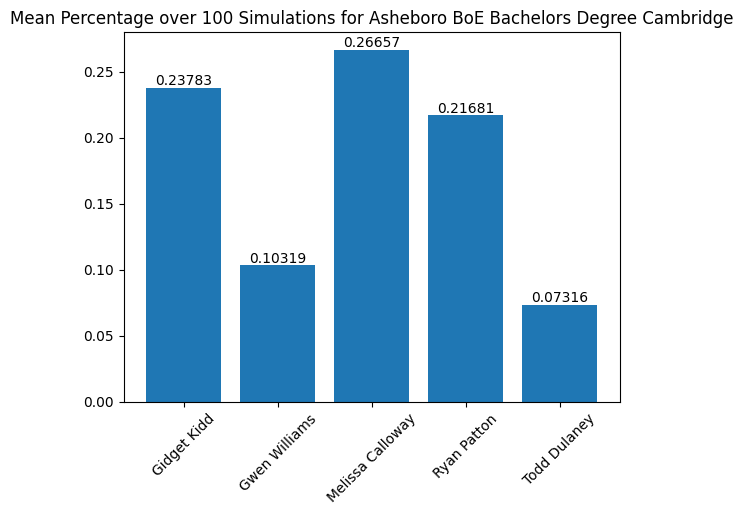

In [9]:
# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_cam = final_cam.astype({col: int for col in final_cam.columns[1:]})
final_cam = final_cam.assign(mean=final_cam.mean(axis=1, numeric_only=True))
final_cam['mean_perc'] = final_cam['mean']/num_votes

fig, ax = plt.subplots()
ax.bar(final_cam['Vote_1'], final_cam['mean_perc'])
ax.tick_params(axis='x', labelrotation=45)
plt.title(f"Mean Percentage over {num_iterations} Simulations for Asheboro BoE Bachelors Degree Cambridge")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

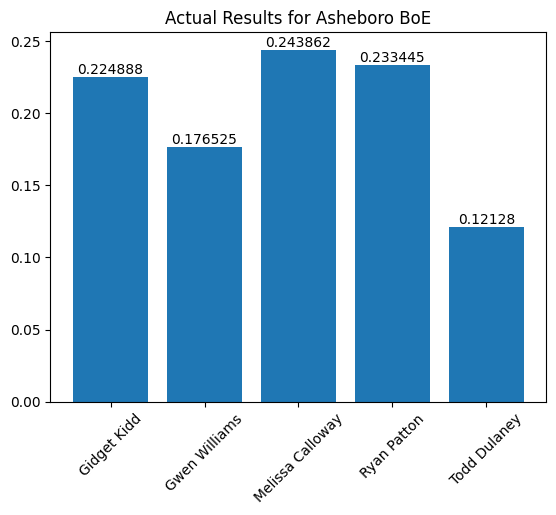

In [10]:
results = pd.read_csv(BASE_DIR / "Election_Data_Sheets" / "csv" / "results_pct_20231107.csv")
results = results[results["Contest Name"] == "ASHEBORO CITY SCHOOLS BOARD OF EDUCATION"]
results = results[["Choice", "Total Votes"]]
results = results.groupby("Choice")['Total Votes'].sum().reset_index()
results = results[results["Choice"] != "Write-In (Miscellaneous)"] #Drop Write-Ins, since that's not a choice in the Simulation

total_votes = results["Total Votes"].sum()
results["Percentage"] = results["Total Votes"] / total_votes

fig, ax = plt.subplots()
ax.bar(results['Choice'], results['Percentage'])
ax.tick_params(axis='x', labelrotation=45)
plt.title("Actual Results for Asheboro BoE")

for container in ax.containers:
    ax.bar_label(container)
    
plt.show

## Determine Ranked-Choice Voting Winner

In [11]:
# read in dfs
bt_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Bachelors Degree_BT.csv")
pl_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Bachelors Degree_PL.csv")
cam_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Bachelors Degree_Cam.csv")

In [12]:
# Ranked Choice Voting Results
bt_results_df = bt_results_df.dropna().reset_index()
grps = bt_results_df.groupby(bt_results_df.index // num_candidates)
all_winners = []
for _, dfg in grps:
    winners = dfg[dfg['STV Result'] == True]
    winners = winners['Candidate'] 
    all_winners.append(list(winners))

all_winners = tuple(all_winners)

counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners in Bradley-Terry: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

Most common winners in Bradley-Terry:  ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']
This occured in 90 iterations out of 100


In [13]:
# Ranked Choice Voting Results
pl_results_df = pl_results_df.dropna().reset_index()
grps = pl_results_df.groupby(pl_results_df.index // num_candidates)
all_winners = []
for _, dfg in grps:
    winners = dfg[dfg['STV Result'] == True]
    winners = winners['Candidate'] 
    all_winners.append(list(winners))

all_winners = tuple(all_winners)

counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners in Placket-Luce: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

Most common winners in Placket-Luce:  ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']
This occured in 94 iterations out of 100


In [14]:
cam_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Bachelors Degree_Cam.csv")
cam_results_df = cam_results_df.dropna().reset_index()
grps = cam_results_df.groupby(cam_results_df.index // num_candidates)
all_winners = []
for _, dfg in grps:
    winners = dfg[dfg['STV Result'] == True]
    winners = winners['Candidate'] 
    all_winners.append(list(winners))

all_winners = tuple(all_winners)

counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners in Cambridge Sampler: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

Most common winners in Cambridge Sampler:  ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']
This occured in 92 iterations out of 100


# Asheboro BoE Black Outputs

In [15]:
# Import the necessary packages
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
BASE_DIR = Path().resolve().parent

In [16]:
# read in dfs
bt_df = pd.read_csv(BASE_DIR / "Results" / "Ballots" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Black_ballots_BT.csv")
pl_df = pd.read_csv(BASE_DIR / "Results" / "Ballots" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Black_ballots_PL.csv")
cam_df = pd.read_csv(BASE_DIR / "Results" / "Ballots" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Black_ballots_Cam.csv")

num_winners = 3 #We need to define this per race
num_votes = 1000 #We can calculate this but I'm too lazy to write the code for it right now


### Clean up the Dataframes

In [17]:
# Right now, rankings are a string. We can turn this into a list, seperating entries on the comma
# We want to expand this so that each vote ranking gets its own row

# BT
candidates = bt_df['ranking'].str.split(",", expand=True)

column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

bt_df = pd.concat([candidates, bt_df.drop('ranking', axis=1)], axis=1)

# Store num_candidates for later:
num_candidates = len(candidates.columns)


# PL
candidates = pl_df['ranking'].str.split(",", expand=True)

column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

pl_df = pd.concat([candidates, pl_df.drop('ranking', axis=1)], axis=1)

# Cam
candidates = cam_df['ranking'].str.split(",", expand=True)

column_names = []
for i in range(len(candidates.columns)):
    column_names.append(f'Vote_{i+1}')
candidates.columns = column_names

cam_df = pd.concat([candidates, cam_df.drop('ranking', axis=1)], axis=1)

## Plot average percentage in Plurality

In [18]:
num_iterations = len(bt_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
bt_df_plur = bt_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_bt = bt_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    bt_df_plur = bt_df[['Vote_1', f'iteration_{i}']]
    temp_df = bt_df_plur.groupby('Vote_1').sum().reset_index()
    final_bt = pd.merge(final_bt, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

In [19]:
num_iterations = len(pl_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
pl_df_plur = pl_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_pl = pl_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    pl_df_plur = pl_df[['Vote_1', f'iteration_{i}']]
    temp_df = pl_df_plur.groupby('Vote_1').sum().reset_index()
    final_pl = pd.merge(final_pl, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

In [20]:
num_iterations = len(cam_df.columns) - len(candidates.columns)

# Do the first by hand
# only keep the columns we actually want
cam_df_plur = cam_df[['Vote_1', 'iteration_1']]
# Sum up total number of votes and get top three winners
final_cam = pl_df_plur.groupby('Vote_1').sum().reset_index()

# Do the rest in a for-loop
for i in range(2, num_iterations+1):
    cam_df_plur = cam_df[['Vote_1', f'iteration_{i}']]
    temp_df = cam_df_plur.groupby('Vote_1').sum().reset_index()
    final_cam = pd.merge(final_cam, temp_df.groupby('Vote_1').sum().reset_index(), on=['Vote_1'], how='outer')

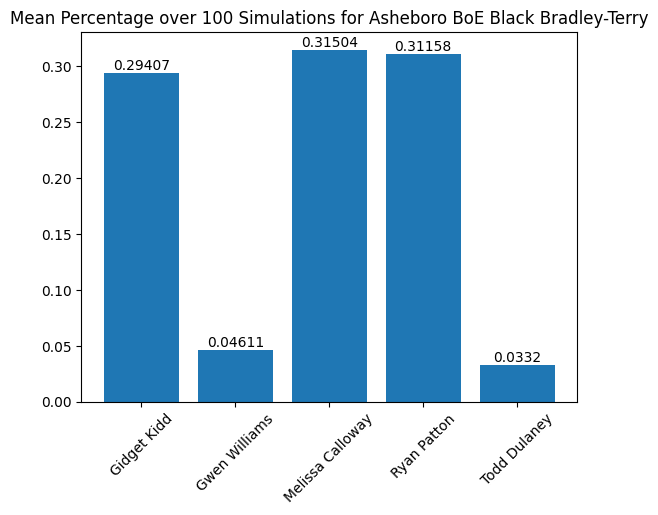

In [21]:
# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_bt = final_bt.astype({col: int for col in final_bt.columns[1:]})
final_bt = final_bt.assign(mean=final_bt.mean(axis=1, numeric_only=True))
final_bt['mean_perc'] = final_bt['mean']/num_votes

fig, ax = plt.subplots()
ax.bar(final_bt['Vote_1'], final_bt['mean_perc'])
ax.tick_params(axis='x', labelrotation=45)
plt.title(f"Mean Percentage over {num_iterations} Simulations for Asheboro BoE Black Bradley-Terry")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

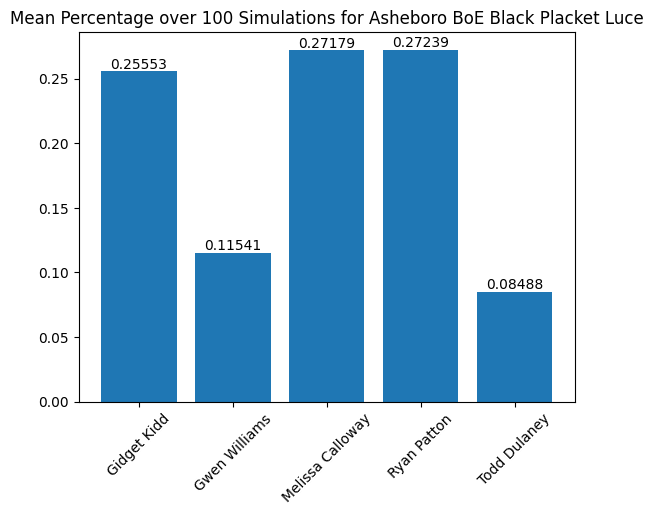

In [22]:
# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_pl = final_pl.astype({col: int for col in final_pl.columns[1:]})
final_pl = final_pl.assign(mean=final_pl.mean(axis=1, numeric_only=True))
final_pl['mean_perc'] = final_pl['mean']/num_votes

fig, ax = plt.subplots()
ax.bar(final_pl['Vote_1'], final_pl['mean_perc'])
ax.tick_params(axis='x', labelrotation=45)
plt.title(f"Mean Percentage over {num_iterations} Simulations for Asheboro BoE Black Placket Luce")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

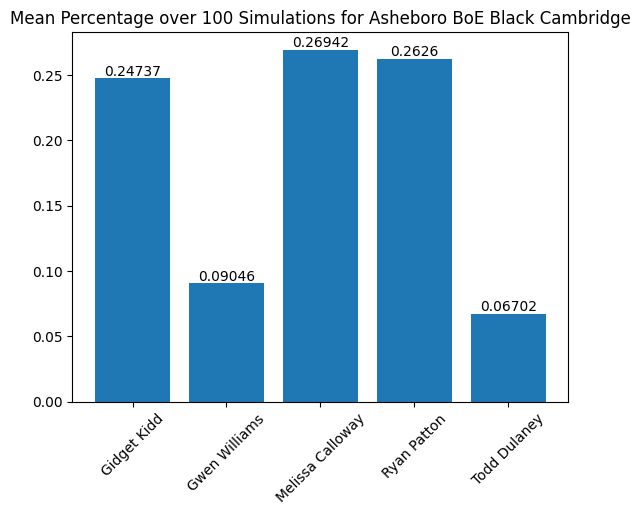

In [23]:
# Source code: https://stackoverflow.com/questions/70893764/how-to-change-the-column-type-of-all-columns-except-the-first-in-pandas
final_cam = final_cam.astype({col: int for col in final_cam.columns[1:]})
final_cam = final_cam.assign(mean=final_cam.mean(axis=1, numeric_only=True))
final_cam['mean_perc'] = final_cam['mean']/num_votes

fig, ax = plt.subplots()
ax.bar(final_cam['Vote_1'], final_cam['mean_perc'])
ax.tick_params(axis='x', labelrotation=45)
plt.title(f"Mean Percentage over {num_iterations} Simulations for Asheboro BoE Black Cambridge")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

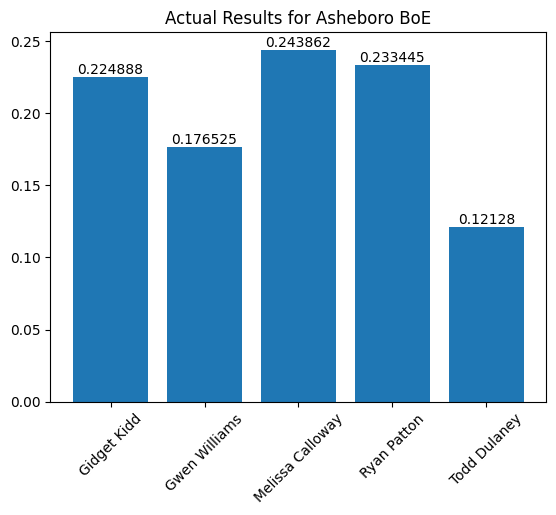

In [24]:
results = pd.read_csv(BASE_DIR / "Election_Data_Sheets" / "csv" / "results_pct_20231107.csv")
results = results[results["Contest Name"] == "ASHEBORO CITY SCHOOLS BOARD OF EDUCATION"]
results = results[["Choice", "Total Votes"]]
results = results.groupby("Choice")['Total Votes'].sum().reset_index()
results = results[results["Choice"] != "Write-In (Miscellaneous)"] #Drop Write-Ins, since that's not a choice in the Simulation

total_votes = results["Total Votes"].sum()
results["Percentage"] = results["Total Votes"] / total_votes

fig, ax = plt.subplots()
ax.bar(results['Choice'], results['Percentage'])
ax.tick_params(axis='x', labelrotation=45)
plt.title("Actual Results for Asheboro BoE")

for container in ax.containers:
    ax.bar_label(container)
    
plt.show

## Determine Ranked-Choice Voting Winner

In [25]:
# read in dfs
bt_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Black_BT.csv")
pl_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Black_PL.csv")
cam_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Black_Cam.csv")

In [26]:
# Ranked Choice Voting Results
bt_results_df = bt_results_df.dropna().reset_index()
grps = bt_results_df.groupby(bt_results_df.index // num_candidates)
all_winners = []
for _, dfg in grps:
    winners = dfg[dfg['STV Result'] == True]
    winners = winners['Candidate'] 
    all_winners.append(list(winners))

all_winners = tuple(all_winners)

counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners in Bradley-Terry: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

Most common winners in Bradley-Terry:  ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']
This occured in 100 iterations out of 100


In [27]:
# Ranked Choice Voting Results
pl_results_df = pl_results_df.dropna().reset_index()
grps = pl_results_df.groupby(pl_results_df.index // num_candidates)
all_winners = []
for _, dfg in grps:
    winners = dfg[dfg['STV Result'] == True]
    winners = winners['Candidate'] 
    all_winners.append(list(winners))

all_winners = tuple(all_winners)

counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners in Placket-Luce: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

Most common winners in Placket-Luce:  ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']
This occured in 100 iterations out of 100


In [28]:
cam_results_df = pd.read_csv(BASE_DIR / "Results" / "Elections" / "Asheboro Sims" / "ashe_sims_Asheboro BoE Bachelors Degree_Cam.csv")
cam_results_df = cam_results_df.dropna().reset_index()
grps = cam_results_df.groupby(cam_results_df.index // num_candidates)
all_winners = []
for _, dfg in grps:
    winners = dfg[dfg['STV Result'] == True]
    winners = winners['Candidate'] 
    all_winners.append(list(winners))

all_winners = tuple(all_winners)

counts = {}
for i in all_winners:
    i = str(i)
    if i in counts:
        counts[i] += 1
    else:
        counts[i] = 1
print("Most common winners in Cambridge Sampler: ", max(counts, key=counts.get))
print("This occured in", max(counts.values()), "iterations out of", len(all_winners))

Most common winners in Cambridge Sampler:  ['Gidget Kidd', 'Melissa Calloway', 'Ryan Patton']
This occured in 92 iterations out of 100
